In [6]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq

from matplotlib.colors import LogNorm
from pathlib import Path
from itertools import combinations
from scipy.stats import binned_statistic_2d
from astropy.io import ascii, fits

In [7]:
INPUT_ROOT = Path("/Users/hyeonghan/Downloads/Dec25-sims-mcoadd-mask-release")
SHEAR_TYPE = "noshear"
MOSAICS = [0, 1, 2, 3]

S2N_COLUMNS = ["snr", "gauss_s2n", "wmom_s2n", "pgauss_s2n"]
FLAG_COLUMN = "flagged"

T_COLUMN = "gauss_T"
TPSF_COLUMN = "gauss_Tpsf"


In [8]:
clusters = ascii.read("/Users/hyeonghan/Downloads/5deg2_cluster.dat")
galaxies = ascii.read("/Users/hyeonghan/Downloads/5deg2_galaxy.dat")

In [9]:
paths = [INPUT_ROOT / f"shear_type={SHEAR_TYPE}" / f"mosaic={mosaic}" / "part-0.parquet" for mosaic in MOSAICS]

In [10]:
tables = []

for path in paths:
    t = pq.read_table(path, columns=S2N_COLUMNS + [FLAG_COLUMN] + [T_COLUMN, TPSF_COLUMN, "gauss_g1", "gauss_g2", "ra", "dec"])
    tables.append(t)

table = pa.concat_tables(tables)

flagged = table[FLAG_COLUMN].to_numpy(zero_copy_only=False).astype(bool)

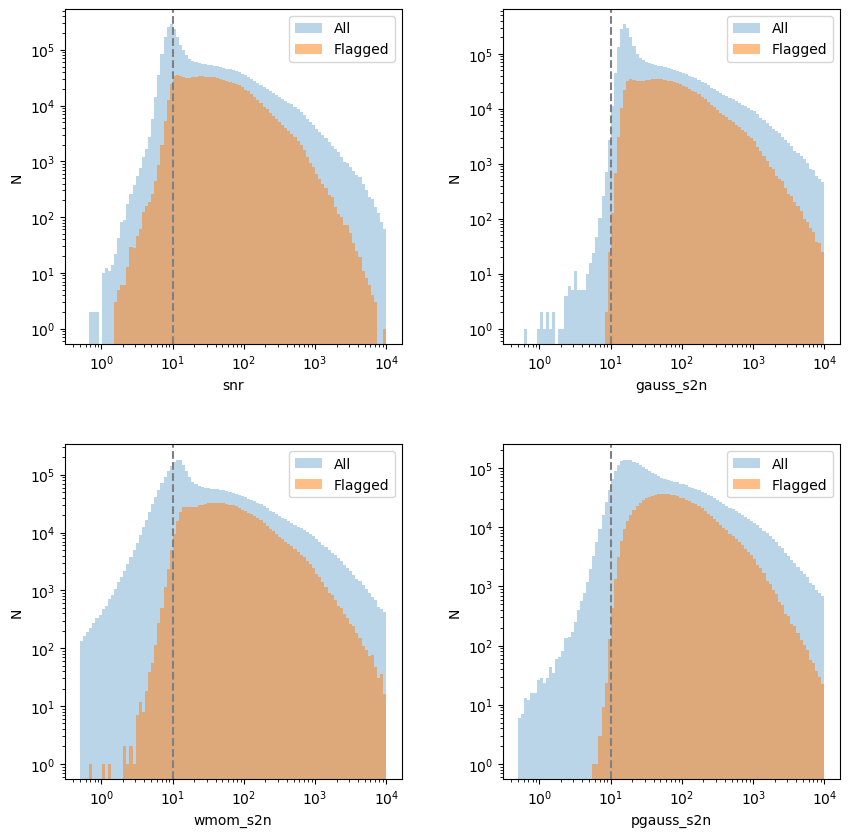

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

bins = np.logspace(np.log10(0.5), np.log10(1e4), 100)

for cnt,ax in enumerate(axes.flat):
    ax.hist(table[S2N_COLUMNS[cnt]], bins=bins, alpha=0.3, label='All')
    ax.hist(table[S2N_COLUMNS[cnt]].to_numpy(zero_copy_only=False)[flagged], bins=bins, alpha=0.5, label='Flagged')

    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.axvline(10, c='gray', ls='--')
    
    ax.set_xlabel(S2N_COLUMNS[cnt])
    ax.set_ylabel('N')
    ax.legend()


fig.subplots_adjust(wspace=0.30, hspace=0.30)

plt.show()

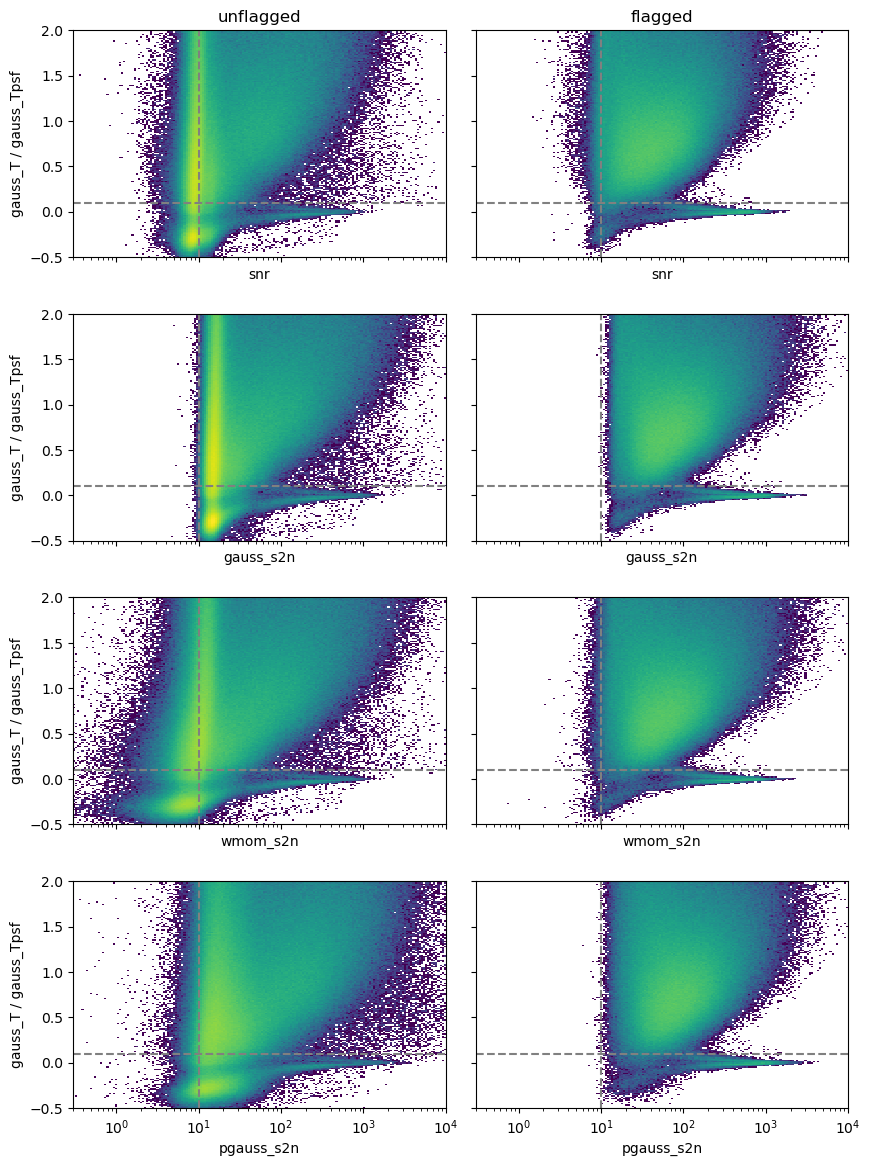

In [13]:

gauss_T = table["gauss_T"].to_numpy(zero_copy_only=False)
gauss_Tpsf = table["gauss_Tpsf"].to_numpy(zero_copy_only=False)
T_ratio = gauss_T / gauss_Tpsf

unflagged = ~flagged

xbins = np.logspace(np.log10(0.3), np.log10(1e4), 180)
ybins = np.linspace(-0.5, 2.0, 180)

histograms = []
global_max = 0

for col in S2N_COLUMNS:
    s2n = table[col].to_numpy(zero_copy_only=False)

    base_mask = (
        np.isfinite(s2n) &
        np.isfinite(T_ratio) &
        (s2n > 0)
    )

    for sample_mask in [unflagged, flagged]:
        mask = base_mask & sample_mask

        H, xedges, yedges = np.histogram2d(s2n[mask], T_ratio[mask], bins=[xbins, ybins])

        histograms.append((col, H, xedges, yedges))
        if H.max() > global_max:
            global_max = H.max()

fig, axes = plt.subplots(nrows=len(S2N_COLUMNS), ncols=2, figsize=(10, 14), sharex=True, sharey=True)

norm = LogNorm(vmin=1, vmax=global_max)


k = 0
for i, col in enumerate(S2N_COLUMNS):
    for j, label in enumerate(["unflagged", "flagged"]):
        ax = axes[i, j]

        _, H, xedges, yedges = histograms[k]
        k += 1

        H = np.ma.masked_where(H == 0, H)

        im = ax.pcolormesh(xedges, yedges, H.T, shading="auto", norm=norm)

        ax.set_xscale("log")
        ax.axvline(10, c="gray", ls="--")
        ax.axhline(0.1, c="gray", ls="--")

        if i == 0:
            ax.set_title(label)

        ax.set_xlabel(col)
        
        if j == 0:
            ax.set_ylabel("gauss_T / gauss_Tpsf")

fig.subplots_adjust(wspace=0.08, hspace=0.25)

plt.show()

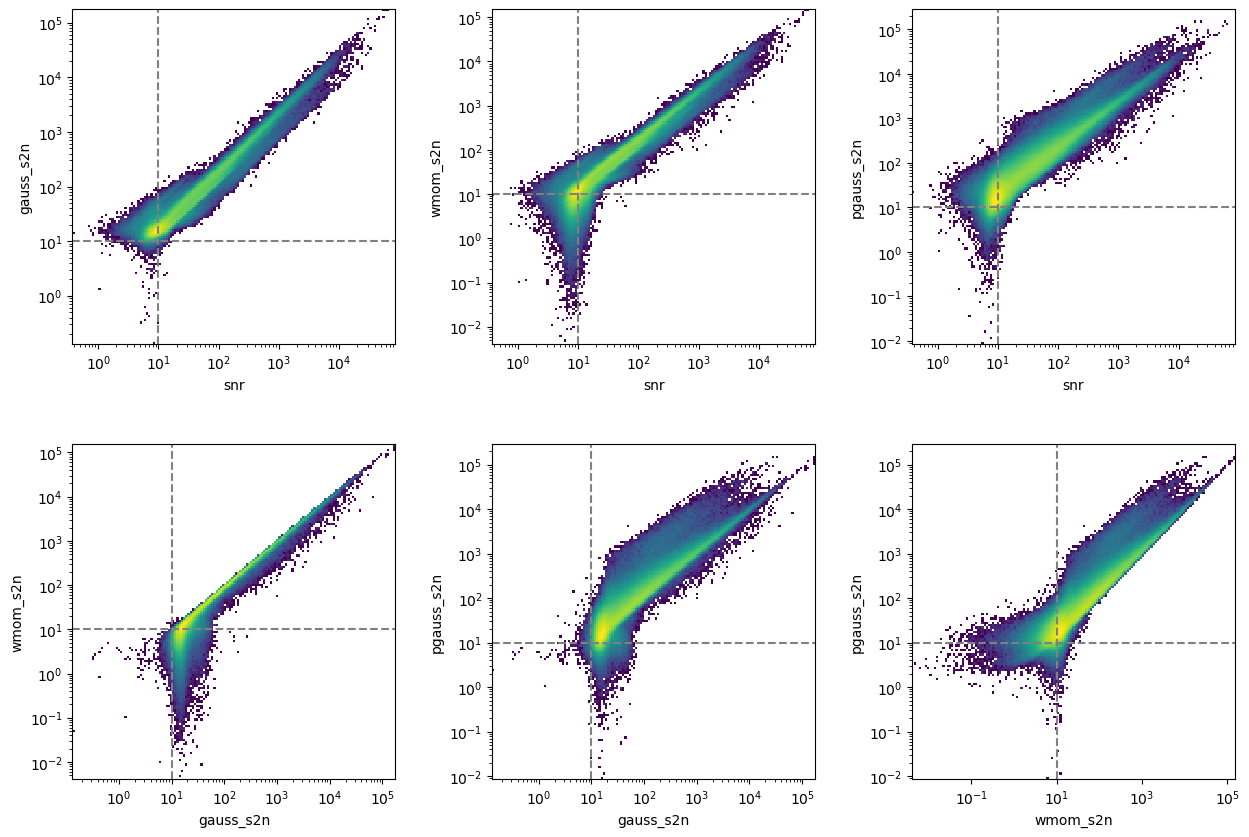

In [14]:
pairs = list(combinations(S2N_COLUMNS, 2))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (xcol, ycol) in zip(axes.flat, pairs):

    x = table[xcol].to_numpy(zero_copy_only=False)
    y = table[ycol].to_numpy(zero_copy_only=False)

    mask = (
        np.isfinite(x) &
        np.isfinite(y) &
        (x > 0) &
        (y > 0)
    )

    x = x[mask]
    y = y[mask]


    xbins = np.logspace( np.log10(x.min()), np.log10(x.max()), 150)
    ybins = np.logspace(np.log10(y.min()), np.log10(y.max()), 150)

    h = ax.hist2d(x, y, bins=[xbins, ybins], norm=LogNorm())

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.axvline(10, c='gray', ls='--')
    ax.axhline(10, c='gray', ls='--')

fig.subplots_adjust(wspace=0.30, hspace=0.30)

plt.show()

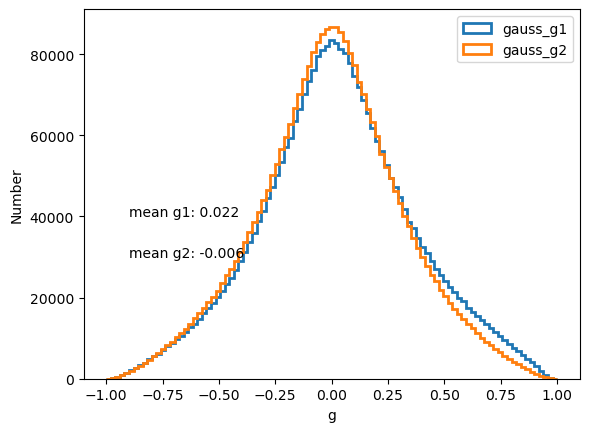

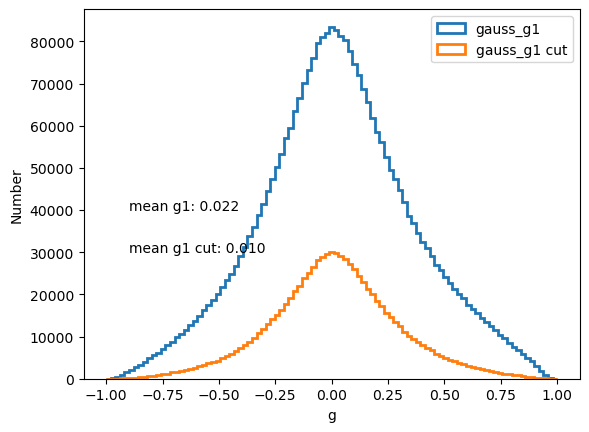

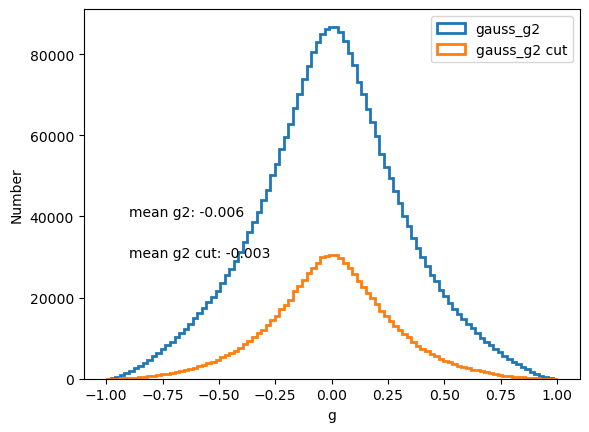

In [18]:
gauss_g1 = table['gauss_g1'].to_numpy(zero_copy_only=False)
gauss_g2 = table['gauss_g2'].to_numpy(zero_copy_only=False)

snr = table['snr'].to_numpy(zero_copy_only=False)

bins = np.linspace(-1, 1, 100)


plt.hist(gauss_g1, bins=bins, histtype='step', lw=2, label='gauss_g1')
plt.hist(gauss_g2, bins=bins, histtype='step', lw=2, label='gauss_g2')
plt.text(-0.9, 40000, "mean g1: {:.3f}".format(np.mean(gauss_g1)))
plt.text(-0.9, 30000, "mean g2: {:.3f}".format(np.mean(gauss_g2)))

plt.xlabel('g')
plt.ylabel('Number')
plt.legend()

plt.show()



sel = np.where((snr>5)
              &(T_ratio > 0.1)
              &flagged
              )[0]

plt.hist(gauss_g1, bins=bins, histtype='step', lw=2, label='gauss_g1')
plt.hist(gauss_g1[sel], bins=bins, histtype='step', lw=2, label='gauss_g1 cut')
plt.text(-0.9, 40000, "mean g1: {:.3f}".format(np.mean(gauss_g1)))
plt.text(-0.9, 30000, "mean g1 cut: {:.3f}".format(np.mean(gauss_g1[sel])))

plt.xlabel('g')
plt.ylabel('Number')
plt.legend()

plt.show()


plt.hist(gauss_g2, bins=bins, histtype='step', lw=2, label='gauss_g2')
plt.hist(gauss_g2[sel], bins=bins, histtype='step', lw=2, label='gauss_g2 cut')
plt.text(-0.9, 40000, "mean g2: {:.3f}".format(np.mean(gauss_g2)))
plt.text(-0.9, 30000, "mean g2 cut: {:.3f}".format(np.mean(gauss_g2[sel])))


plt.xlabel('g')
plt.ylabel('Number')
plt.legend()

plt.show()

# Not calibrated!

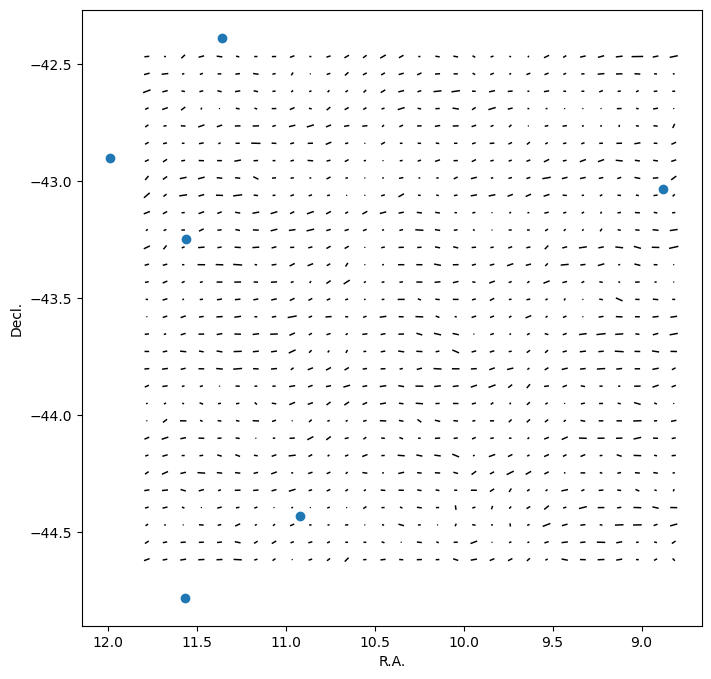

In [24]:

x = table['ra'].to_numpy(zero_copy_only=False)
y = table['dec'].to_numpy(zero_copy_only=False)

e1 = table['gauss_g1'].to_numpy(zero_copy_only=False)
e2 = table['gauss_g2'].to_numpy(zero_copy_only=False)

NBIN = 30

mask = (
    np.isfinite(x) &
    np.isfinite(y) &
    np.isfinite(e1) &
    np.isfinite(e2)
)

x = x[mask]
y = y[mask]
e1 = e1[mask]
e2 = e2[mask]

mean_e1, xedges, yedges, _ = binned_statistic_2d(
    x,
    y,
    e1,
    statistic='mean',
    bins=NBIN
)

mean_e2, _, _, _ = binned_statistic_2d(
    x,
    y,
    e2,
    statistic='mean',
    bins=[xedges, yedges]
)


count, _, _, _ = binned_statistic_2d(
    x,
    y,
    e1,
    statistic='count',
    bins=[xedges, yedges]
)


xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])

X, Y = np.meshgrid(xc, yc, indexing='ij')

ellip = np.sqrt(mean_e1**2 + mean_e2**2)

theta = 0.5 * np.arctan2(
    mean_e2,
    mean_e1
)

U = ellip * np.cos(theta)
V = ellip * np.sin(theta)


good = (
    np.isfinite(U) &
    np.isfinite(V) &
    (count > 10)
)


fig, ax = plt.subplots(figsize=(8, 8))

q = ax.quiver(
    X[good],
    Y[good],
    U[good],
    V[good],
    angles='xy',
    scale_units='xy',
    scale=1,
    pivot='middle',
    headwidth=0,
    headlength=0,
    headaxislength=0
)

sel_clu = np.where(clusters['halo_mass']>4e14)[0]

#ax.scatter(clusters['ra'], clusters['dec'])
ax.scatter(clusters['ra'][sel_clu], clusters['dec'][sel_clu])


ax.set_xlabel('R.A.')
ax.set_ylabel('Decl.')
plt.gca().invert_xaxis()
plt.show()

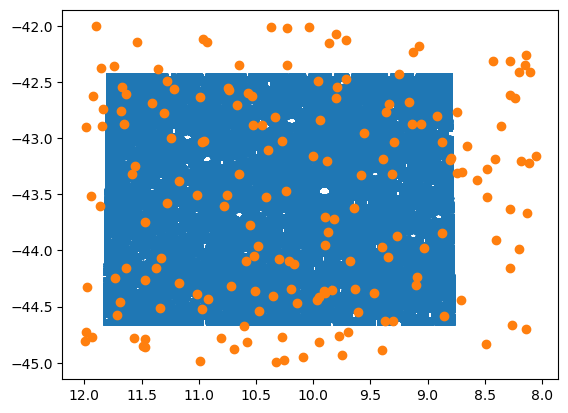

In [23]:
x = table['ra'].to_numpy(zero_copy_only=False)
y = table['dec'].to_numpy(zero_copy_only=False)
plt.scatter(x, y, s=1)
plt.scatter(clusters['ra'], clusters['dec'])

plt.gca().invert_xaxis()
plt.show()